# Micro-sam for instance segmentation

In this notebook, we want to try out automatic [instance segmentation](https://medium.com/@abhishekjainindore24/semantic-vs-instance-vs-panoptic-segmentation-b1f5023da39f) using [micro-sam](https://github.com/computational-cell-analytics/micro-sam). 

It is inspired by the [automatic-segmentation notebook in the micro-sam github repository](https://github.com/computational-cell-analytics/micro-sam/blob/master/notebooks/automatic_segmentation.ipynb) as well as two introductory notebooks written by Robert [here](https://github.com/ScaDS/BIDS-lecture-2024/blob/main/09c_micro_sam/micro-sam.ipynb) and [here](https://github.com/haesleinhuepf/micro-sam/blob/0f3e49026fce6f065f377724d12ea29b4b590017/notebooks/quick_start.ipynb).

You can install micro-sam in a conda environment like this. If you never worked with conda-environments before, consider reading [this blog post](https://biapol.github.io/blog/mara_lampert/getting_started_with_miniforge_and_python/readme.html) first.

`conda install -c conda-forge micro_sam`

Let us first import everything we need:

In [1]:
from micro_sam.automatic_segmentation import get_predictor_and_segmenter, automatic_instance_segmentation
from skimage.io import imread
import matplotlib.pyplot as plt

INFO:OpenGL.acceleratesupport:No OpenGL_accelerate module loaded: No module named 'OpenGL_accelerate'


As an example image, we use [a fluorescence microscopy dataset published by M. Arvidsson et al.](https://zenodo.org/records/6657260) showing Hoechst 33342-stained nuclei, licensed [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/).

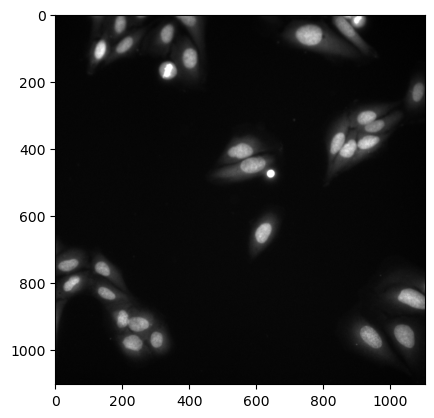

In [ ]:
# Load microscopy image
image = imread("../../data/development_nuclei.png")

# Show input image
plt.imshow(image, cmap="gray")

First, we load a segmentation model and its helper (`predictor` and `segmenter`) that are trained to recognize and separate different structures in an image. Then, we apply them to our input image to create a label image (`label_image`), where each detected object is assigned a unique label, making the segmentation ready for further analysis.

In [4]:
# Load model
predictor, segmenter = get_predictor_and_segmenter(model_type="vit_b_lm")

# Apply model
label_image = automatic_instance_segmentation(predictor=predictor, segmenter=segmenter, input_path=image)

Using apple MPS device.


Initialize instance segmentation with decoder: 100%|██████████| 1/1 [00:00<00:00,  2.90it/s]


Now, we can investigate the results.

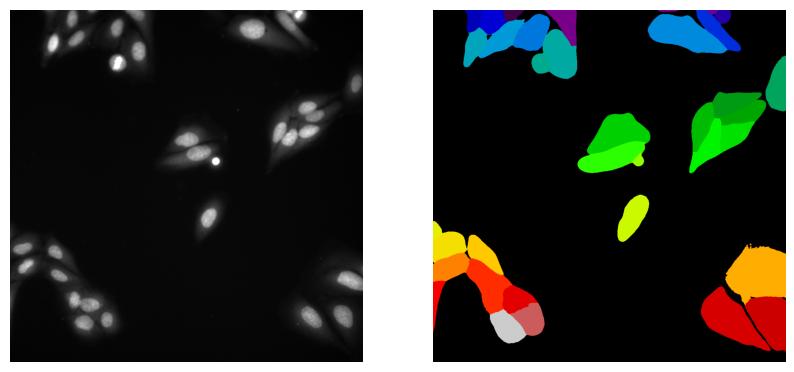

In [ ]:
# show image and label image side-by-sid
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(label_image, cmap="nipy_spectral")
plt.axis("off")
plt.show()


If you want to dive further into this topic, see the [linked jupyter notebooks](https://github.com/computational-cell-analytics/micro-sam/tree/master/notebooks) as well as this [video playlist](https://www.youtube.com/playlist?list=PLwYZXQJ3f36GQPpKCrSbHjGiH39X4XjSO).

## Exercise 

We have used the model `vit_b_lm`. Try out another one, for example `vit_b_em_organelles` which is specialized for electron microscopy and organelle segmentation. Which differences in the segmentation result can you observe and why do you think this is the case?